In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
valid_loader = DataLoader(valid_dataset, batch_size=64)

(11610, 8) (5160, 8) (3870, 8)


In [4]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [23]:
def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	clip_grad=False
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			if clip_grad=True:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=2)
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (338801247.py, line 27)

Epoch: 1/30, Loss: 0.654, Train Metric: 0.562, Valid Metric: 0.552
Epoch: 2/30, Loss: 0.459, Train Metric: 0.484, Valid Metric: 0.465
Epoch: 3/30, Loss: 0.436, Train Metric: 0.471, Valid Metric: 0.52
Epoch: 4/30, Loss: 0.42, Train Metric: 0.461, Valid Metric: 0.473
Epoch: 5/30, Loss: 0.41, Train Metric: 0.457, Valid Metric: 0.466
Epoch: 6/30, Loss: 0.407, Train Metric: 0.451, Valid Metric: 0.456
Epoch: 7/30, Loss: 0.412, Train Metric: 0.453, Valid Metric: 0.493
Epoch: 8/30, Loss: 0.389, Train Metric: 0.444, Valid Metric: 0.447
Epoch: 9/30, Loss: 0.381, Train Metric: 0.44, Valid Metric: 0.458
Epoch: 10/30, Loss: 0.383, Train Metric: 0.437, Valid Metric: 0.442
Epoch: 11/30, Loss: 0.374, Train Metric: 0.434, Valid Metric: 0.453
Epoch: 12/30, Loss: 0.371, Train Metric: 0.432, Valid Metric: 0.506
Epoch: 13/30, Loss: 0.371, Train Metric: 0.433, Valid Metric: 0.423
Epoch: 14/30, Loss: 0.374, Train Metric: 0.431, Valid Metric: 0.534
Epoch: 15/30, Loss: 0.358, Train Metric: 0.427, Valid Metric:

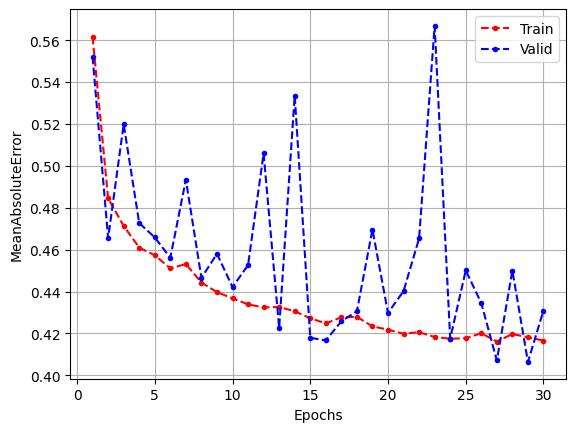

In [ ]:
learning_rate = 0.2
n_epochs=30

model = nn.Sequential(
    nn.Linear(8, 16),
    nn.LeakyReLU(),
    nn.Linear(16, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 16),
    nn.LeakyReLU(),
    nn.Linear(16, 8),
    nn.LeakyReLU(),
    nn.Linear(16, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, weight_decay=1e-4)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    clip_grad=True
    )
plot_history(history, n_epochs, metric)